## 7. Server Implementation Strategy

Equivalent HTTP servers were implemented using each runtime's native HTTP API:

- Node.js: `node:http`
- Bun: `Bun.serve()`
- Deno: `Deno.serve()`

No third-party web framework was introduced. This reduced dependency-related variation and allowed each runtime's native HTTP server implementation to be evaluated.

All implementations:

- Listen on `127.0.0.1:3000`.
- Implement `GET /json`.
- Return HTTP status code 200.
- Return the same fixed JSON body.
- Return `application/json; charset=utf-8`.
- Perform no database or file-system access.
- Perform no external network access.
- Perform no per-request logging.
- Emit a structured message when the server is ready.

The fixed response body was created before request handling so that repeated JSON serialisation was not included in the measured workload.

## 8. Initial Functional Validation

Before performance testing, each server was started individually and accessed through the same URL.

The validation checked:

1. Whether the server started successfully.
2. Whether `GET /json` returned HTTP 200.
3. Whether the content type was correct.
4. Whether the response body exactly matched the expected JSON string.
5. Whether an unsupported route returned HTTP 404.

Performance testing will only proceed after functional equivalence has been confirmed for all three implementations.

## 9. HTTP Load-Generation Tool

Autocannon was selected as the HTTP load-generation tool for the benchmark.

It permits the experimental workload to be configured using parameters including concurrent connections, test duration and HTTP pipelining. It can also produce machine-readable JSON output for subsequent preprocessing in R.

Autocannon was installed as an exact local development dependency so that the version used by the project could be recorded and reproduced.

The same Autocannon installation and workload configuration will be used when testing Node.js, Bun and Deno.

## 10. Initial Smoke-Test Configuration

An initial smoke test was conducted to verify the complete HTTP data-generation pipeline.

| Parameter | Smoke-test value |
|---|---:|
| Endpoint | `GET /json` |
| Concurrent connections | 10 |
| Duration | 10 seconds |
| Pipelining factor | 1 |
| Repetitions | 1 per runtime |
| Output format | JSON |
| Dataset category | Pilot |

These values were selected only to confirm that each runtime could be tested successfully and that the generated output could be stored for analysis. They do not represent the final experimental configuration.

## 11. Smoke-Test Data Import and Inspection

The initial smoke tests generated one JSON result file for each runtime. These files contain the HTTP workload configuration, request-rate statistics, latency statistics, data throughput and diagnostic error counts.

The smoke-test results are imported into R to verify that the output is machine-readable and can be converted into a consistent tabular dataset.

These results are diagnostic pilot observations and will not be included in the final statistical analysis.

In [1]:
if (!requireNamespace("jsonlite", quietly = TRUE)) {
  install.packages("jsonlite")
}

library(jsonlite)

In [ ]:
#find plot directory

candidate_directories <- c(
  "data/pilot/http",
  "../data/pilot/http"
)

available_directories <- candidate_directories[
  dir.exists(candidate_directories)
]

if (length(available_directories) == 0) {
  stop("The data/pilot/http directory could not be located.")
}

pilot_directory <- normalizePath(
  available_directories[1],
  winslash = "/",
  mustWork = TRUE
)

pilot_directory

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http"

In [3]:
# Identify smoke files

runtime_files <- c(
  "Node.js" = "node_smoke.json",
  "Bun" = "bun_smoke.json",
  "Deno" = "deno_smoke.json"
)

smoke_paths <- file.path(
  pilot_directory,
  unname(runtime_files)
)

file_check <- data.frame(
  runtime = names(runtime_files),
  file = smoke_paths,
  exists = file.exists(smoke_paths)
)

file_check

runtime,file,exists
<chr>,<chr>,<lgl>
Node.js,D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/node_smoke.json,TRUE
Bun,D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/bun_smoke.json,TRUE
Deno,D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/deno_smoke.json,TRUE


In [4]:
# Add a Strict check
if (!all(file_check$exists)) {
  stop("One or more smoke-test files are missing.")
}

In [5]:
# Extract result from Each JSON file

extract_http_smoke_result <- function(runtime, filename) {
  result <- jsonlite::fromJSON(
    file.path(pilot_directory, filename)
  )

  data.frame(
    runtime = runtime,
    url = result$url,
    connections = result$connections,
    pipelining = result$pipelining,
    workers = result$workers,
    duration_s = result$duration,
    samples = result$samples,
    start_utc = result$start,
    finish_utc = result$finish,

    total_requests = result$requests$total,
    requests_per_second = result$requests$average,
    requests_per_second_sd = result$requests$stddev,
    minimum_requests_per_second = result$requests$min,
    maximum_requests_per_second = result$requests$max,

    mean_latency_ms = result$latency$mean,
    median_latency_ms = result$latency$p50,
    p90_latency_ms = result$latency$p90,
    p97_5_latency_ms = result$latency$p97_5,
    p99_latency_ms = result$latency$p99,
    maximum_latency_ms = result$latency$max,
    latency_sd_ms = result$latency$stddev,

    bytes_per_second = result$throughput$average,
    megabytes_per_second = result$throughput$average / 1000000,
    total_bytes = result$throughput$total,

    errors = result$errors,
    timeouts = result$timeouts,
    mismatches = result$mismatches,
    non_2xx = result$non2xx,
    successful_2xx = result[["2xx"]],
    successful_200 = result$statusCodeStats[["200"]]$count,

    stringsAsFactors = FALSE
  )
}

In [7]:
# Combine the three results

smoke_rows <- Map(
  f = extract_http_smoke_result,
  runtime = names(runtime_files),
  filename = unname(runtime_files)
)

http_smoke_summary <- do.call(
  rbind,
  smoke_rows
)

rownames(http_smoke_summary) <- NULL

http_smoke_summary

runtime,url,connections,pipelining,workers,duration_s,samples,start_utc,finish_utc,total_requests,⋯,latency_sd_ms,bytes_per_second,megabytes_per_second,total_bytes,errors,timeouts,mismatches,non_2xx,successful_2xx,successful_200
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Node.js,http://127.0.0.1:3000/json,10,1,0,10.02,10,2026-08-02T16:35:45.362Z,2026-08-02T16:35:55.384Z,144870,⋯,0.65,3621888,3.621888,36217500,0,0,0,0,144870,144870
Bun,http://127.0.0.1:3000/json,10,1,0,10.04,10,2026-08-02T16:37:15.994Z,2026-08-02T16:37:26.030Z,151882,⋯,6.10,2794611,2.794611,27946288,0,0,0,0,151882,151882
Deno,http://127.0.0.1:3000/json,10,1,0,10.03,10,2026-08-02T16:38:36.550Z,2026-08-02T16:38:46.575Z,161335,⋯,4.11,2968768,2.968768,29685640,0,0,0,0,161335,161335


In [8]:
# Display main measurements

http_smoke_summary[
  ,
  c(
    "runtime",
    "connections",
    "duration_s",
    "total_requests",
    "requests_per_second",
    "mean_latency_ms",
    "median_latency_ms",
    "p97_5_latency_ms",
    "p99_latency_ms",
    "errors",
    "timeouts",
    "non_2xx"
  )
]

runtime,connections,duration_s,total_requests,requests_per_second,mean_latency_ms,median_latency_ms,p97_5_latency_ms,p99_latency_ms,errors,timeouts,non_2xx
<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
Node.js,10,10.02,144870,14488.4,0.09,0,1,1,0,0,0
Bun,10,10.04,151882,15187.8,0.23,0,2,3,0,0,0
Deno,10,10.03,161335,16132.8,0.13,0,0,1,0,0,0


In [9]:
# Validate the results

smoke_validation <- data.frame(
  check = c(
    "Three runtime files were imported",
    "All runs used 10 connections",
    "All runs used pipelining of 1",
    "No connection errors occurred",
    "No timeouts occurred",
    "No response-body mismatches occurred",
    "No non-2xx responses occurred",
    "All completed requests returned HTTP 200"
  ),

  passed = c(
    nrow(http_smoke_summary) == 3,
    all(http_smoke_summary$connections == 10),
    all(http_smoke_summary$pipelining == 1),
    all(http_smoke_summary$errors == 0),
    all(http_smoke_summary$timeouts == 0),
    all(http_smoke_summary$mismatches == 0),
    all(http_smoke_summary$non_2xx == 0),
    all(
      http_smoke_summary$total_requests ==
        http_smoke_summary$successful_200
    )
  )
)

smoke_validation

check,passed
<chr>,<lgl>
Three runtime files were imported,TRUE
All runs used 10 connections,TRUE
All runs used pipelining of 1,TRUE
No connection errors occurred,TRUE
No timeouts occurred,TRUE
No response-body mismatches occurred,TRUE
No non-2xx responses occurred,TRUE
All completed requests returned HTTP 200,TRUE


In [10]:
# Add strict validation

if (!all(smoke_validation$passed)) {
  warning("One or more HTTP smoke-test checks failed.")
}

In [11]:
#Save summary

smoke_summary_path <- file.path(
  pilot_directory,
  "http_smoke_summary.csv"
)

write.csv(
  http_smoke_summary,
  smoke_summary_path,
  row.names = FALSE
)

smoke_summary_path

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/http_smoke_summary.csv"

## 12. Smoke-Test Outcome

The three Autocannon JSON files were successfully imported into R and converted into a common tabular structure containing one observation per runtime.

The validation checks examined the workload configuration, connection errors, timeouts, mismatched response bodies, non-successful status codes and completed HTTP 200 responses.

The smoke test established that:

- All three servers could be exercised using the same load-generation tool.
- Autocannon produced machine-readable output for every runtime.
- The resulting JSON files could be imported and transformed using R.
- Throughput, latency and diagnostic measurements could be extracted consistently.
- The initial HTTP dataset-generation pipeline was operational.

The smoke-test measurements are not treated as final performance findings because only one short execution was conducted for each runtime.

## 13. Repeated HTTP Pilot Design

Following successful completion of the smoke test, a repeated pilot experiment was designed to evaluate the stability of the HTTP benchmark and identify suitable workload settings for final data collection.

The pilot uses three concurrent-connection levels:

* 10 connections, representing a relatively light workload.
* 50 connections, representing an intermediate workload.
* 100 connections, representing a higher workload.

Each runtime and connection-level combination will be executed three times. Every measured execution will use a newly started server process and will be preceded by a short warm-up workload.

### Pilot configuration

| Parameter              |                         Pilot value |
| ---------------------- | ----------------------------------: |
| Endpoint               |                         `GET /json` |
| Connection levels      |                      10, 50 and 100 |
| Pipelining factor      |                                   1 |
| Warm-up duration       |                           5 seconds |
| Measured duration      |                          20 seconds |
| Repetitions            |                                   3 |
| Runtimes               |               Node.js, Bun and Deno |
| Server process         | Restarted before every measured run |
| Cool-down interval     |                           5 seconds |
| Output format          |                                JSON |
| Dataset classification |                               Pilot |

The runtime execution order will be rotated across repetitions to reduce the possibility that one runtime systematically benefits or suffers from always being tested first.

These settings are provisional. The pilot results will be used to determine the connection levels, duration, warm-up procedure and repetition count used during final data collection.


## 14. Automated Pilot Runner Validation

Before automating the complete repeated pilot, the runner was tested using one Node.js observation at ten concurrent connections.

The runner automatically:

1. Started a fresh Node.js server process.
2. Checked that the HTTP endpoint was ready.
3. Applied a five-second warm-up workload.
4. Conducted a separate twenty-second measured workload.
5. Validated and saved the Autocannon JSON result.
6. Terminated the server process after completion.

### Validation configuration

| Parameter | Value |
|---|---:|
| Runtime | Node.js |
| Connections | 10 |
| Pipelining | 1 |
| Warm-up duration | 5 seconds |
| Measured duration | 20 seconds |
| Timeout | 10 seconds |
| Repetition | 1 |

The measured run completed successfully without connection errors, timeouts or non-2xx responses. This established that the automated start, readiness, warm-up, measurement, data-storage and shutdown sequence functioned correctly.

The observation remains pilot data and is not interpreted as a final comparison result.

## 15. Repeated Pilot Data Import

The repeated HTTP pilot produced separate JSON files for every combination of runtime, concurrent-connection level and repetition.

The files are imported and combined into a single tabular dataset so that workload completeness, execution errors, measurement stability and performance patterns can be examined.

In [2]:
# Locate repeated piot folder
library(jsonlite)

candidate_directories <- c(
  "data/pilot/http/repeated",
  "../data/pilot/http/repeated"
)

available_directories <- candidate_directories[
  dir.exists(candidate_directories)
]

if (length(available_directories) == 0) {
  stop("The repeated HTTP pilot directory could not be located.")
}

pilot_directory <- normalizePath(
  available_directories[1],
  winslash = "/",
  mustWork = TRUE
)

pilot_directory

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/repeated"

In [3]:
#Find only the repeated 27 json files

pilot_files <- list.files(
  path = pilot_directory,
  pattern = "^(node|bun|deno)_c[0-9]{3}_r[0-9]{2}\\.json$",
  full.names = TRUE
)

length(pilot_files)

[1] 27

In [4]:
# file checker
if (length(pilot_files) != 27) {
  warning(
    paste(
      "Expected 27 JSON files but found",
      length(pilot_files)
    )
  )
}

In [5]:
# Extraction funciton
extract_http_pilot_result <- function(path) {
  filename <- basename(path)

  filename_match <- regexec(
    "^(node|bun|deno)_c([0-9]{3})_r([0-9]{2})\\.json$",
    filename
  )

  filename_parts <- regmatches(
    filename,
    filename_match
  )[[1]]

  if (length(filename_parts) != 4) {
    stop(paste("Unexpected pilot filename:", filename))
  }

  result <- jsonlite::fromJSON(path)

  requests_per_second <- result$requests$average
  bytes_per_second <- result$throughput$average

  data.frame(
    run_id = sub("\\.json$", "", filename),
    runtime = filename_parts[2],
    connections = as.integer(filename_parts[3]),
    repetition = as.integer(filename_parts[4]),

    url = result$url,
    pipelining = result$pipelining,
    workers = result$workers,
    duration_s = result$duration,
    samples = result$samples,
    start_utc = result$start,
    finish_utc = result$finish,

    total_requests = result$requests$total,
    requests_per_second = requests_per_second,
    requests_per_second_sd = result$requests$stddev,
    minimum_requests_per_second = result$requests$min,
    maximum_requests_per_second = result$requests$max,

    mean_latency_ms = result$latency$mean,
    median_latency_ms = result$latency$p50,
    p90_latency_ms = result$latency$p90,
    p97_5_latency_ms = result$latency$p97_5,
    p99_latency_ms = result$latency$p99,
    maximum_latency_ms = result$latency$max,
    latency_sd_ms = result$latency$stddev,

    bytes_per_second = bytes_per_second,
    bytes_per_request = (
      bytes_per_second / requests_per_second
    ),

    errors = result$errors,
    timeouts = result$timeouts,
    mismatches = result$mismatches,
    non_2xx = result$non2xx,
    successful_2xx = result[["2xx"]],

    stringsAsFactors = FALSE
  )
}

In [6]:
#combine all files
pilot_rows <- lapply(
  pilot_files,
  extract_http_pilot_result
)

http_pilot <- do.call(
  rbind,
  pilot_rows
)

rownames(http_pilot) <- NULL

http_pilot <- http_pilot[
  order(
    http_pilot$runtime,
    http_pilot$connections,
    http_pilot$repetition
  ),
]

http_pilot

,run_id,runtime,connections,repetition,url,pipelining,workers,duration_s,samples,start_utc,⋯,p99_latency_ms,maximum_latency_ms,latency_sd_ms,bytes_per_second,bytes_per_request,errors,timeouts,mismatches,non_2xx,successful_2xx
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,bun_c010_r01,bun,10,1,http://127.0.0.1:3000/json,1,0,20.02,20,2026-08-03T11:41:44.341Z,⋯,3,28,0.69,2862618,183.9823,0,0,0,0,311156
2,bun_c010_r02,bun,10,2,http://127.0.0.1:3000/json,1,0,20.03,20,2026-08-03T11:46:14.749Z,⋯,4,79,1.30,2127718,183.9759,0,0,0,0,231286
3,bun_c010_r03,bun,10,3,http://127.0.0.1:3000/json,1,0,20.03,20,2026-08-03T11:52:08.217Z,⋯,3,32,0.66,2942182,183.9876,0,0,0,0,319805
4,bun_c050_r01,bun,50,1,http://127.0.0.1:3000/json,1,0,20.06,20,2026-08-03T11:43:33.457Z,⋯,6,55,1.16,2978816,183.9979,0,0,0,0,323787
5,bun_c050_r02,bun,50,2,http://127.0.0.1:3000/json,1,0,20.08,20,2026-08-03T11:47:51.334Z,⋯,9,65,1.57,2391834,183.9815,0,0,0,0,259996
6,bun_c050_r03,bun,50,3,http://127.0.0.1:3000/json,1,0,20.06,20,2026-08-03T11:53:44.450Z,⋯,7,78,1.62,2948838,183.9988,0,0,0,0,320521
7,bun_c100_r01,bun,100,1,http://127.0.0.1:3000/json,1,0,20.13,20,2026-08-03T11:45:09.510Z,⋯,11,105,1.93,3016499,183.9935,0,0,0,0,327864
8,bun_c100_r02,bun,100,2,http://127.0.0.1:3000/json,1,0,20.08,20,2026-08-03T11:49:27.932Z,⋯,11,79,1.75,2867814,183.9923,0,0,0,0,311713
9,bun_c100_r03,bun,100,3,http://127.0.0.1:3000/json,1,0,20.10,20,2026-08-03T11:55:20.745Z,⋯,12,91,1.98,2944333,184.0070,0,0,0,0,320023


In [7]:
# validate
pilot_validation <- data.frame(
  check = c(
    "Twenty-seven observations imported",
    "Nine observations per runtime",
    "Nine observations per connection level",
    "Three repetitions per runtime and connection level",
    "All runs used pipelining of one",
    "No connection errors",
    "No timeouts",
    "No response mismatches",
    "No non-2xx responses",
    "All completed responses were 2xx"
  ),

  passed = c(
    nrow(http_pilot) == 27,

    all(
      table(http_pilot$runtime) == 9
    ),

    all(
      table(http_pilot$connections) == 9
    ),

    all(
      table(
        http_pilot$runtime,
        http_pilot$connections
      ) == 3
    ),

    all(http_pilot$pipelining == 1),
    all(http_pilot$errors == 0),
    all(http_pilot$timeouts == 0),
    all(http_pilot$mismatches == 0),
    all(http_pilot$non_2xx == 0),

    all(
      http_pilot$total_requests ==
        http_pilot$successful_2xx
    )
  )
)

pilot_validation

check,passed
<chr>,<lgl>
Twenty-seven observations imported,TRUE
Nine observations per runtime,TRUE
Nine observations per connection level,TRUE
Three repetitions per runtime and connection level,TRUE
All runs used pipelining of one,TRUE
No connection errors,TRUE
No timeouts,TRUE
No response mismatches,TRUE
No non-2xx responses,TRUE


In [8]:
# Save into a csv file

combined_pilot_path <- file.path(
  pilot_directory,
  "http_repeated_pilot_combined.csv"
)

write.csv(
  http_pilot,
  combined_pilot_path,
  row.names = FALSE
)

combined_pilot_path

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/pilot/http/repeated/http_repeated_pilot_combined.csv"

## 16. Repeated Pilot Stability Analysis

The repeated pilot dataset was analysed to determine whether the proposed HTTP workload produced consistent and interpretable measurements.

The analysis focuses on:

1. Variation in requests per second across repeated executions.
2. Changes in throughput as concurrent connections increase.
3. Changes in mean and tail latency under increasing load.
4. Evidence of unusually slow or unstable experimental sessions.
5. The suitability of the proposed warm-up, measurement duration, connection levels and repetition count.

The pilot results are used only to refine the experimental procedure. They are not treated as final comparative findings.


In [9]:
required_packages <- c(
  "dplyr",
  "ggplot2"
)

packages_to_install <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(packages_to_install) > 0) {
  install.packages(packages_to_install)
}

library(dplyr)
library(ggplot2)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [11]:
dim(http_pilot)
names(http_pilot)
exists("http_pilot")

[1] 27 30

[1] "run_id"                      "runtime"                    
 [3] "connections"                 "repetition"                 
 [5] "url"                         "pipelining"                 
 [7] "workers"                     "duration_s"                 
 [9] "samples"                     "start_utc"                  
[11] "finish_utc"                  "total_requests"             
[13] "requests_per_second"         "requests_per_second_sd"     
[15] "minimum_requests_per_second" "maximum_requests_per_second"
[17] "mean_latency_ms"             "median_latency_ms"          
[19] "p90_latency_ms"              "p97_5_latency_ms"           
[21] "p99_latency_ms"              "maximum_latency_ms"         
[23] "latency_sd_ms"               "bytes_per_second"           
[25] "bytes_per_request"           "errors"                     
[27] "timeouts"                    "mismatches"                 
[29] "non_2xx"                     "successful_2xx"

[1] TRUE

In [12]:
http_pilot <- http_pilot |>
  mutate(
    runtime = factor(
      runtime,
      levels = c("node", "bun", "deno"),
      labels = c("Node.js", "Bun", "Deno")
    ),
    connections = as.integer(connections),
    repetition = as.integer(repetition)
  )

str(http_pilot)

'data.frame':	27 obs. of  30 variables:
 $ run_id                     : chr  "bun_c010_r01" "bun_c010_r02" "bun_c010_r03" "bun_c050_r01" ...
 $ runtime                    : Factor w/ 3 levels "Node.js","Bun",..: 2 2 2 2 2 2 2 2 2 3 ...
 $ connections                : int  10 10 10 50 50 50 100 100 100 10 ...
 $ repetition                 : int  1 2 3 1 2 3 1 2 3 1 ...
 $ url                        : chr  "http://127.0.0.1:3000/json" "http://127.0.0.1:3000/json" "http://127.0.0.1:3000/json" "http://127.0.0.1:3000/json" ...
 $ pipelining                 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ workers                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ duration_s                 : num  20 20 20 20.1 20.1 ...
 $ samples                    : int  20 20 20 20 20 20 20 20 20 20 ...
 $ start_utc                  : chr  "2026-08-03T11:41:44.341Z" "2026-08-03T11:46:14.749Z" "2026-08-03T11:52:08.217Z" "2026-08-03T11:43:33.457Z" ...
 $ finish_utc                 : chr  "2026-08-03T11:42:04.364Z" "2026-

In [13]:
# calculate throughput stability

throughput_summary <- http_pilot |>
  group_by(
    runtime,
    connections
  ) |>
  summarise(
    observations = n(),

    mean_requests_per_second = mean(
      requests_per_second
    ),

    median_requests_per_second = median(
      requests_per_second
    ),

    standard_deviation = sd(
      requests_per_second
    ),

    coefficient_of_variation_percent = (
      standard_deviation /
        mean_requests_per_second
    ) * 100,

    minimum_requests_per_second = min(
      requests_per_second
    ),

    maximum_requests_per_second = max(
      requests_per_second
    ),

    range_requests_per_second = (
      maximum_requests_per_second -
        minimum_requests_per_second
    ),

    .groups = "drop"
  ) |>
  mutate(
    across(
      where(is.numeric),
      \(value) round(value, 2)
    )
  )

throughput_summary

runtime,connections,observations,mean_requests_per_second,median_requests_per_second,standard_deviation,coefficient_of_variation_percent,minimum_requests_per_second,maximum_requests_per_second,range_requests_per_second
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Node.js,10,3,14074.17,14832.8,1599.14,11.36,12236.9,15152.8,2915.9
Node.js,50,3,14415.27,14399.7,253.31,1.76,14170.1,14676.0,505.9
Node.js,100,3,14157.47,14199.2,165.79,1.17,13974.8,14298.4,323.6
Bun,10,3,14371.87,15559.2,2440.22,16.98,11565.2,15991.2,4426.0
Bun,50,3,15072.07,16026.4,1795.97,11.92,13000.4,16189.4,3189.0
Bun,100,3,15994.13,16001.2,404.05,2.53,15586.6,16394.6,808.0
Deno,10,3,16610.87,17616.0,1923.71,11.58,14392.8,17823.8,3431.0
Deno,50,3,16494.73,17821.6,2801.78,16.99,13276.0,18386.6,5110.6
Deno,100,3,15133.90,16202.2,3005.97,19.86,11739.7,17459.8,5720.1


In [14]:
# calcluate latency summaries

latency_summary <- http_pilot |>
  group_by(
    runtime,
    connections
  ) |>
  summarise(
    observations = n(),

    mean_of_mean_latency_ms = mean(
      mean_latency_ms
    ),

    median_of_mean_latency_ms = median(
      mean_latency_ms
    ),

    standard_deviation_mean_latency_ms = sd(
      mean_latency_ms
    ),

    mean_p90_latency_ms = mean(
      p90_latency_ms
    ),

    mean_p97_5_latency_ms = mean(
      p97_5_latency_ms
    ),

    mean_p99_latency_ms = mean(
      p99_latency_ms
    ),

    maximum_p99_latency_ms = max(
      p99_latency_ms
    ),

    maximum_observed_latency_ms = max(
      maximum_latency_ms
    ),

    .groups = "drop"
  ) |>
  mutate(
    across(
      where(is.numeric),
      \(value) round(value, 2)
    )
  )

latency_summary

runtime,connections,observations,mean_of_mean_latency_ms,median_of_mean_latency_ms,standard_deviation_mean_latency_ms,mean_p90_latency_ms,mean_p97_5_latency_ms,mean_p99_latency_ms,maximum_p99_latency_ms,maximum_observed_latency_ms
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Node.js,10,3,0.09,0.07,0.03,0.33,1.00,1.33,2,34
Node.js,50,3,2.99,2.99,0.07,4.00,5.00,7.33,8,110
Node.js,100,3,6.56,6.54,0.08,8.00,9.67,14.00,14,106
Bun,10,3,0.19,0.15,0.07,0.00,3.33,3.33,4,79
Bun,50,3,2.87,2.64,0.42,4.33,5.67,7.33,9,78
Bun,100,3,5.77,5.76,0.16,7.00,8.67,11.33,12,105
Deno,10,3,0.06,0.04,0.03,0.00,1.00,1.00,1,38
Deno,50,3,2.65,2.38,0.54,3.33,4.67,6.67,9,73
Deno,100,3,6.33,5.68,1.52,8.00,12.33,19.00,34,134


In [15]:
#display all repititions

repetition_table <- http_pilot |>
  select(
    runtime,
    connections,
    repetition,
    requests_per_second,
    mean_latency_ms,
    p99_latency_ms,
    errors,
    timeouts,
    non_2xx
  ) |>
  arrange(
    connections,
    repetition,
    runtime
  )

repetition_table

runtime,connections,repetition,requests_per_second,mean_latency_ms,p99_latency_ms,errors,timeouts,non_2xx
<fct>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
Node.js,10,1,14832.8,0.07,1,0,0,0
Bun,10,1,15559.2,0.15,3,0,0,0
Deno,10,1,17616.0,0.04,1,0,0,0
Node.js,10,2,12236.9,0.13,2,0,0,0
Bun,10,2,11565.2,0.27,4,0,0,0
Deno,10,2,14392.8,0.10,1,0,0,0
Node.js,10,3,15152.8,0.07,1,0,0,0
Bun,10,3,15991.2,0.15,3,0,0,0
Deno,10,3,17823.8,0.04,1,0,0,0


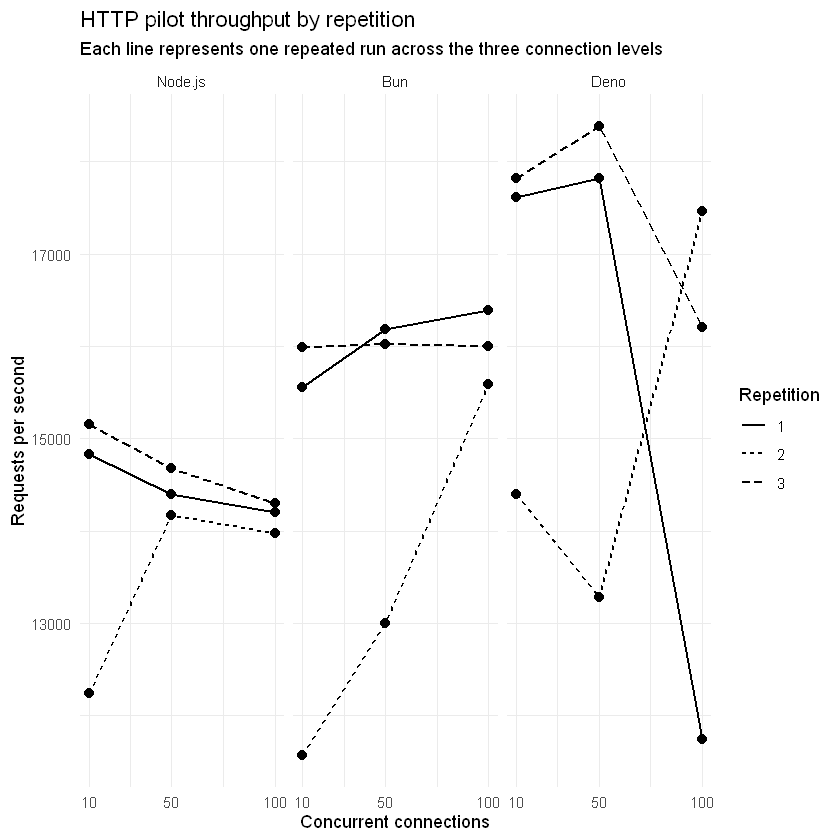

In [16]:
# plot throughput across repitions

throughput_repetition_plot <- ggplot(
  http_pilot,
  aes(
    x = connections,
    y = requests_per_second,
    group = factor(repetition),
    linetype = factor(repetition)
  )
) +
  geom_line(
    linewidth = 0.8
  ) +
  geom_point(
    size = 2.5
  ) +
  facet_wrap(
    ~ runtime
  ) +
  scale_x_continuous(
    breaks = c(10, 50, 100)
  ) +
  labs(
    title = "HTTP pilot throughput by repetition",
    subtitle = paste(
      "Each line represents one repeated run",
      "across the three connection levels"
    ),
    x = "Concurrent connections",
    y = "Requests per second",
    linetype = "Repetition"
  ) +
  theme_minimal()

throughput_repetition_plot

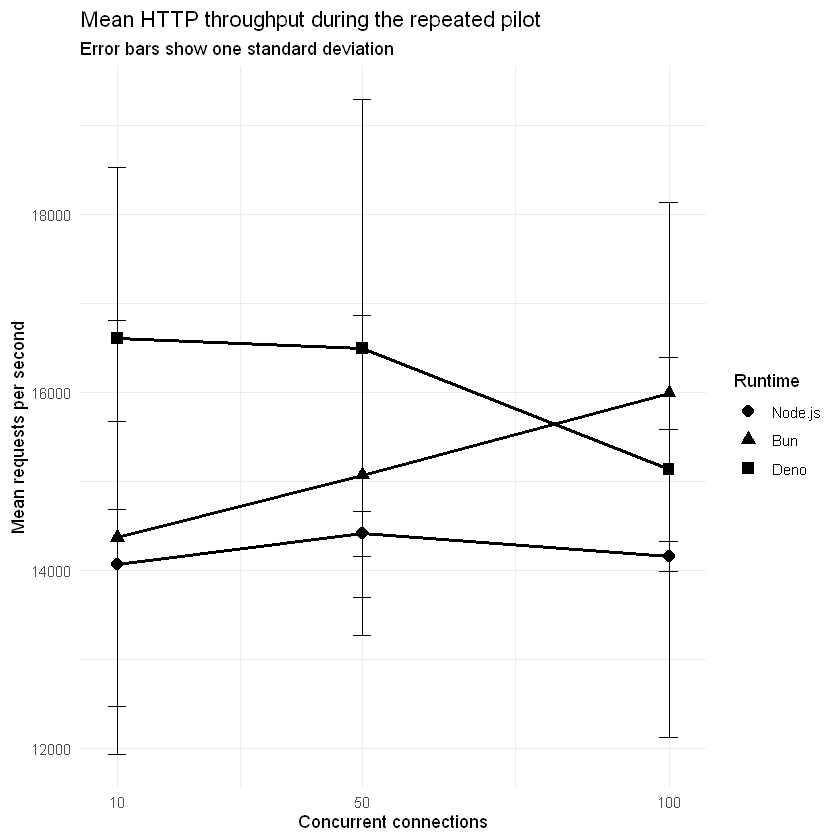

In [17]:
# plot throughput by variability

throughput_summary_plot <- ggplot(
  throughput_summary,
  aes(
    x = connections,
    y = mean_requests_per_second,
    group = runtime,
    shape = runtime
  )
) +
  geom_line(
    linewidth = 0.9
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = mean_requests_per_second -
        standard_deviation,
      ymax = mean_requests_per_second +
        standard_deviation
    ),
    width = 3
  ) +
  scale_x_continuous(
    breaks = c(10, 50, 100)
  ) +
  labs(
    title = "Mean HTTP throughput during the repeated pilot",
    subtitle = "Error bars show one standard deviation",
    x = "Concurrent connections",
    y = "Mean requests per second",
    shape = "Runtime"
  ) +
  theme_minimal()

throughput_summary_plot

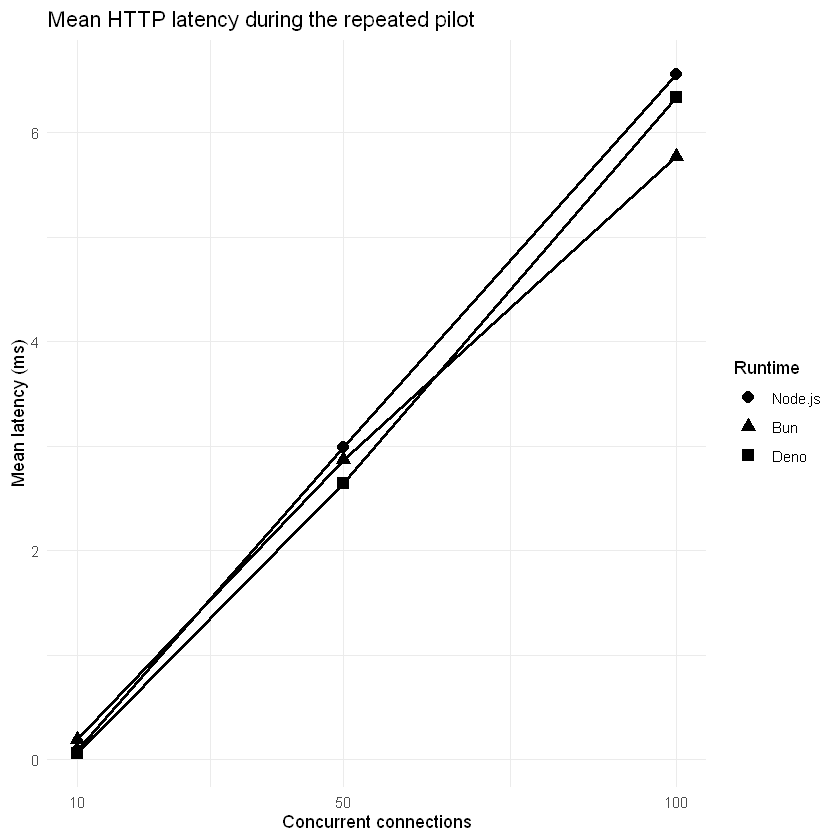

In [18]:
# plot mean latency

mean_latency_plot <- ggplot(
  http_pilot,
  aes(
    x = connections,
    y = mean_latency_ms,
    group = runtime,
    shape = runtime
  )
) +
  stat_summary(
    fun = mean,
    geom = "line",
    linewidth = 0.9
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    size = 3
  ) +
  scale_x_continuous(
    breaks = c(10, 50, 100)
  ) +
  labs(
    title = "Mean HTTP latency during the repeated pilot",
    x = "Concurrent connections",
    y = "Mean latency (ms)",
    shape = "Runtime"
  ) +
  theme_minimal()

mean_latency_plot

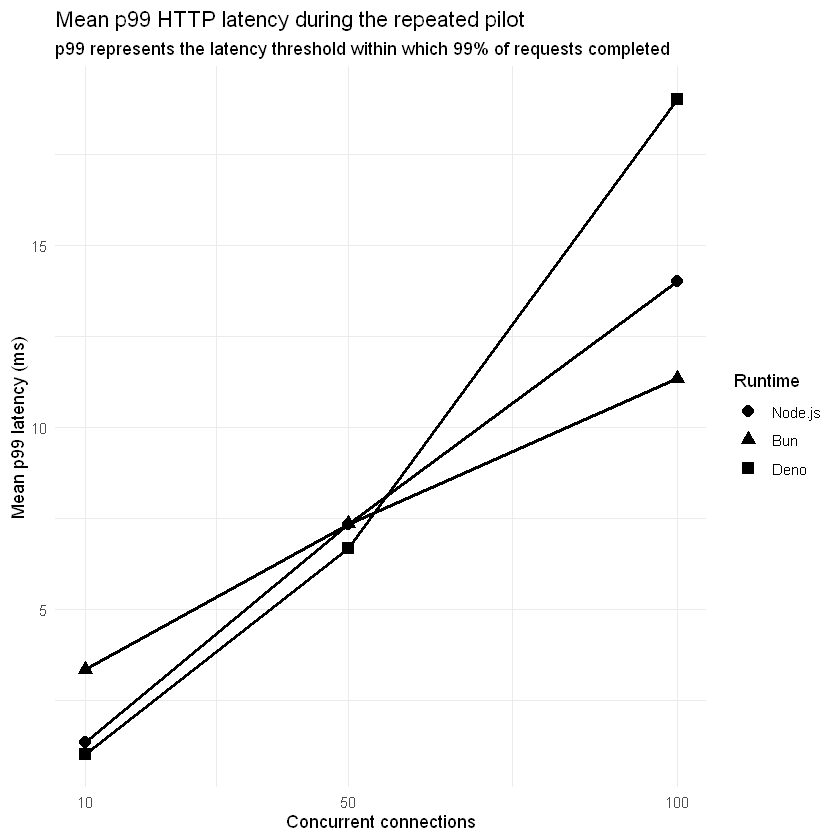

In [19]:
# Plot p99(99%) latency

p99_latency_plot <- ggplot(
  http_pilot,
  aes(
    x = connections,
    y = p99_latency_ms,
    group = runtime,
    shape = runtime
  )
) +
  stat_summary(
    fun = mean,
    geom = "line",
    linewidth = 0.9
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    size = 3
  ) +
  scale_x_continuous(
    breaks = c(10, 50, 100)
  ) +
  labs(
    title = "Mean p99 HTTP latency during the repeated pilot",
    subtitle = paste(
      "p99 represents the latency threshold",
      "within which 99% of requests completed"
    ),
    x = "Concurrent connections",
    y = "Mean p99 latency (ms)",
    shape = "Runtime"
  ) +
  theme_minimal()

p99_latency_plot

In [21]:
# check for possible repitition effect

http_pilot_indexed <- http_pilot |>
  group_by(
    runtime,
    connections
  ) |>
  mutate(
    group_mean_requests_per_second = mean(
      requests_per_second
    ),

    throughput_index_percent = (
      requests_per_second /
        group_mean_requests_per_second
    ) * 100
  ) |>
  ungroup()

In [22]:
#summarise by repitition

repetition_effect_summary <- http_pilot_indexed |>
  group_by(repetition) |>
  summarise(
    mean_throughput_index_percent = mean(
      throughput_index_percent
    ),

    median_throughput_index_percent = median(
      throughput_index_percent
    ),

    standard_deviation_index = sd(
      throughput_index_percent
    ),

    .groups = "drop"
  ) |>
  mutate(
    across(
      where(is.numeric),
      \(value) round(value, 2)
    )
  )

repetition_effect_summary

repetition,mean_throughput_index_percent,median_throughput_index_percent,standard_deviation_index
<dbl>,<dbl>,<dbl>,<dbl>
1,101.71,105.39,9.60
2,92.29,86.95,11.25
3,105.99,107.06,4.20


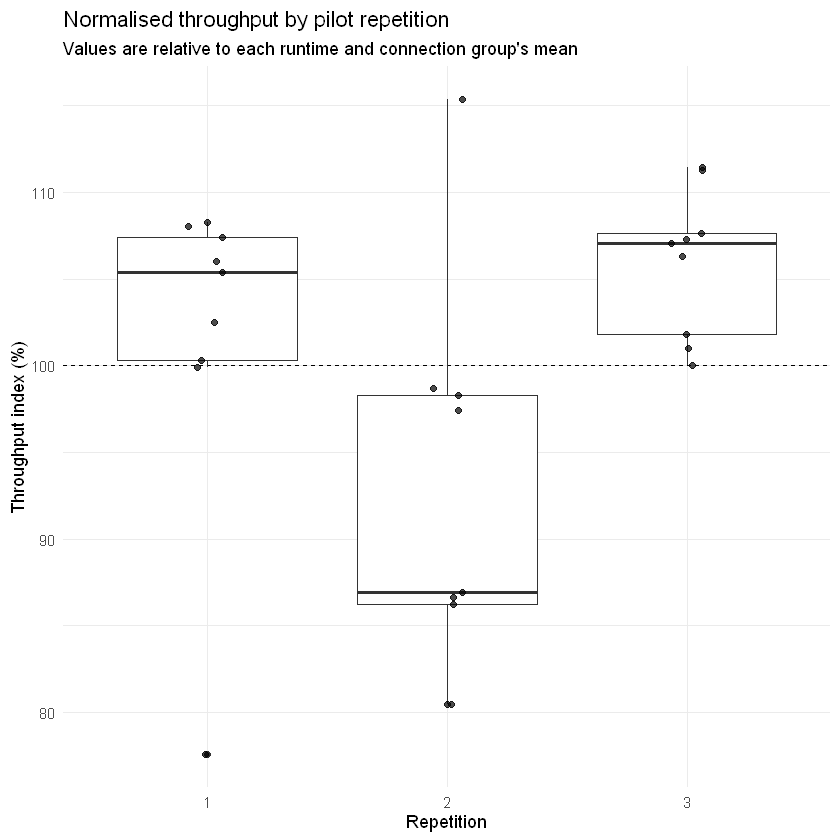

In [24]:
# plot it 
repetition_effect_plot <- ggplot(
  http_pilot_indexed,
  aes(
    x = factor(repetition),
    y = throughput_index_percent
  )
) +
  geom_hline(
    yintercept = 100,
    linetype = "dashed"
  ) +
  geom_boxplot() +
  geom_jitter(
    width = 0.08,
    height = 0,
    alpha = 0.7
  ) +
  labs(
    title = "Normalised throughput by pilot repetition",
    subtitle = paste(
      "Values are relative to each runtime",
      "and connection group's mean"
    ),
    x = "Repetition",
    y = "Throughput index (%)"
  ) +
  theme_minimal()

repetition_effect_plot

In [25]:
# save Ananlysis outputs 
project_root <- if (
  dir.exists("results")
) {
  "."
} else {
  ".."
}

table_directory <- file.path(
  project_root,
  "results",
  "tables"
)

figure_directory <- file.path(
  project_root,
  "results",
  "figures"
)

dir.create(
  table_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

dir.create(
  figure_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

In [26]:
#save tables

write.csv(
  throughput_summary,
  file.path(
    table_directory,
    "http_pilot_throughput_summary.csv"
  ),
  row.names = FALSE
)

write.csv(
  latency_summary,
  file.path(
    table_directory,
    "http_pilot_latency_summary.csv"
  ),
  row.names = FALSE
)

write.csv(
  repetition_effect_summary,
  file.path(
    table_directory,
    "http_pilot_repetition_effect_summary.csv"
  ),
  row.names = FALSE
)

In [28]:
#save figures
ggsave(
  filename = file.path(
    figure_directory,
    "http_pilot_throughput_repetitions.png"
  ),
  plot = throughput_repetition_plot,
  width = 10,
  height = 6,
  dpi = 300
)

ggsave(
  filename = file.path(
    figure_directory,
    "http_pilot_mean_throughput.png"
  ),
  plot = throughput_summary_plot,
  width = 9,
  height = 6,
  dpi = 300
)

ggsave(
  filename = file.path(
    figure_directory,
    "http_pilot_mean_latency.png"
  ),
  plot = mean_latency_plot,
  width = 9,
  height = 6,
  dpi = 300
)

ggsave(
  filename = file.path(
    figure_directory,
    "http_pilot_p99_latency.png"
  ),
  plot = p99_latency_plot,
  width = 9,
  height = 6,
  dpi = 300
)

ggsave(
  filename = file.path(
    figure_directory,
    "http_pilot_repetition_effect.png"
  ),
  plot = repetition_effect_plot,
  width = 8,
  height = 6,
  dpi = 300
)


## 17. Pilot Rationale, Findings and Final Experimental Adjustments

### Rationale for pilot testing

Pilot testing was conducted before final data collection to verify the complete HTTP benchmarking pipeline and determine whether the proposed workload settings produced reliable and interpretable measurements.

The pilot was required because the study generates its own primary dataset. It was therefore necessary to validate not only the runtime implementations, but also the server-startup procedure, warm-up process, load generation, data storage, JSON extraction and R preprocessing workflow.

The pilot data were used to refine the experimental procedure and are excluded from the final comparative dataset.

### Pilot configuration

The repeated pilot evaluated Node.js, Bun and Deno at 10, 50 and 100 concurrent connections. Each runtime and connection-level combination was tested three times.

Each observation used:

- A five-second warm-up.
- A twenty-second measured workload.
- A pipelining factor of one.
- A ten-second timeout.
- A fresh server process.
- A five-second cool-down interval.

This generated 27 pilot observations.

### Pilot findings

All pilot observations completed successfully. No connection errors, timeouts, response mismatches or non-2xx responses were recorded.

The selected connection levels created distinct workload conditions. Mean and p99 latency increased as concurrent connections increased, confirming that 10, 50 and 100 connections represented progressively heavier server loads.

Throughput results showed noticeable variation across repeated executions. The second repetition was generally weaker than the first and third repetitions, suggesting that temporary machine or session conditions affected some observations.

Variation was particularly noticeable for several Bun and Deno configurations. Three repetitions were therefore considered insufficient for reliable final comparisons.

The pilot also showed that native HTTP response sizes differed among the runtimes because of differences in automatically generated response headers. Requests per second was consequently selected as the primary HTTP throughput metric, while byte throughput was retained only as a secondary diagnostic measure.

### Final experimental adjustments

Based on the pilot findings, the following changes were applied to the final HTTP experiment:

| Experimental feature | Final decision |
|---|---|
| HTTP endpoint | Fixed `GET /json` response retained |
| Connection levels | 10, 50 and 100 retained |
| Pipelining factor | 1 retained |
| Request timeout | 10 seconds retained |
| Warm-up duration | Increased from 5 to 10 seconds |
| Measured duration | Increased from 20 to 30 seconds |
| Repetitions | Increased from 3 to 10 per configuration |
| Cool-down interval | Increased from 5 to 10 seconds |
| Execution order | All runtime and connection combinations randomised within each repetition block |
| Data collection | Divided into multiple controlled sessions |
| Primary throughput metric | Requests per second |
| Tail-latency metric | p99 latency |
| Pilot data | Excluded from final analysis |

Following these adjustments, the HTTP experimental protocol was frozen before final data collection.

## 18. Final Complex HTTP Benchmark Implementation

### Purpose of the complex workload

The simple HTTP benchmark measured the ability of Node.js, Bun and Deno to return a fixed JSON response with minimal application-level processing. A second, more complex HTTP workload was implemented to evaluate runtime performance under a controlled request-processing task.

The complex workload required each runtime to:

1. Receive an HTTP POST request.
2. read a fixed JSON request body;
3. parse the JSON payload;
4. validate the supplied values;
5. iterate through an array of order items;
6. calculate the item count, subtotal, discount and final total;
7. create a new response object;
8. serialise the response object to JSON; and
9. return the dynamically generated response.

The workload remained intentionally controlled. It did not include a database, file access, an external API, authentication, a web framework or other third-party application dependencies. This ensured that the comparison remained focused on HTTP handling, JSON processing and JavaScript execution within each runtime.

### Complex HTTP endpoint

The complex benchmark used the following endpoint:

- Method: `POST`
- URL: `http://127.0.0.1:3000/process`
- Content type: `application/json`

Every measured request used the same fixed JSON payload:

```json
{
  "customerId": 1204,
  "items": [
    {
      "productId": 1,
      "quantity": 2,
      "price": 15.5
    },
    {
      "productId": 2,
      "quantity": 1,
      "price": 30
    },
    {
      "productId": 3,
      "quantity": 4,
      "price": 7.25
    }
  ],
  "discountRate": 0.1
}

 ```json
{
  "customerId": 1204,
  "itemCount": 7,
  "subtotal": 90,
  "discount": 9,
  "total": 81,
  "status": "processed"
}



### 18.3 Implementation equivalence

Three native HTTP server implementations were created:

- Node.js using the native `node:http` module;
- Bun using `Bun.serve()`; and
- Deno using `Deno.serve()`.

The implementations did not use third-party web frameworks.

A shared ECMAScript module contained the validation and order-processing logic used by all three servers. This reduced the possibility that different validation rules or calculations would affect the runtime comparison.

The processing function:

- confirmed that the request body was a JSON object;
- validated the customer identifier and discount rate;
- confirmed that the items property was a non-empty array;
- validated each product identifier, quantity and price;
- calculated monetary values using integer pence before converting them back to pounds; and
- created a new result object for JSON serialisation.

Using integer pence reduced the risk of inconsistent floating-point monetary calculations.

### 18.4 Functional validation

Functional validation was completed before final performance measurements were collected.

Each Node.js, Bun and Deno server was started separately. The fixed JSON fixture was then submitted to the `/process` endpoint.

For every runtime, validation confirmed that:

- the server started successfully;
- the endpoint accepted an HTTP POST request;
- the response status was HTTP 200;
- the response content type was JSON; and
- the raw response body exactly matched the expected JSON string.

All three implementations passed the functional-equivalence check.

A separate complex-workload pilot was not conducted. The load generator, warm-up procedure, execution automation, output format and session-based collection process had already been tested during the simple HTTP pilot. Functional validation was therefore used to confirm the correctness of the newly introduced complex workload before final collection.

### 18.5 Final complex HTTP protocol

The complex workload used the same load configuration as the final simple HTTP benchmark. Keeping the protocol consistent allowed workload complexity to be examined without changing the connection levels, duration, repetition count or load-generation procedure.

| Experimental property | Final complex HTTP configuration |
|---|---|
| Runtime | Node.js, Bun and Deno |
| Endpoint | `POST /process` |
| Connection levels | 10, 50 and 100 |
| Pipelining | 1 |
| Request timeout | 10 seconds |
| Warm-up duration | 10 seconds |
| Measured duration | 30 seconds |
| Cool-down interval | 10 seconds |
| Repetitions | 10 per runtime and connection combination |
| Sessions | 2 |
| Observations per session | 45 |
| Total observations | 90 |
| Primary throughput measure | Requests per second |
| Latency measures | Mean, median, p90, p97.5, p99 and maximum latency |

The nine runtime-and-connection combinations were randomised within each repetition using a fixed random seed. Repetitions 1–5 were collected during the first session, while repetitions 6–10 were collected during the second session.

The Python runner automatically:

1. started the required runtime server;
2. checked server readiness;
3. validated the complex response;
4. performed an unrecorded warm-up;
5. executed the measured Autocannon workload;
6. saved the raw JSON result;
7. updated the experiment manifest;
8. stopped the server process; and
9. applied the cool-down interval.

The runner also recorded the runtime versions, protocol configuration and SHA-256 hashes of the request fixture, shared processing module and server implementations. These hashes were used to detect implementation changes between collection sessions.

In [4]:
library(dplyr)

candidate_manifest_paths <- c(
  "data/raw/http/complex/http_complex_final_manifest.csv",
  "../data/raw/http/complex/http_complex_final_manifest.csv"
)

available_manifest_paths <- candidate_manifest_paths[
  file.exists(candidate_manifest_paths)
]

if (length(available_manifest_paths) == 0) {
  stop(
    paste(
      "The complex HTTP manifest could not be found.",
      "Check the current notebook working directory."
    )
  )
}

complex_manifest_path <- normalizePath(
  available_manifest_paths[1],
  winslash = "/",
  mustWork = TRUE
)

complex_http_manifest <- read.csv(
  complex_manifest_path,
  stringsAsFactors = FALSE
)

cat("Manifest path:\n", complex_manifest_path, "\n\n")
cat("Rows:", nrow(complex_http_manifest), "\n")
cat("Columns:", ncol(complex_http_manifest), "\n")


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Manifest path:
 D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/raw/http/complex/http_complex_final_manifest.csv 

Rows: 90 
Columns: 35 


In [5]:
complex_structure_summary <- complex_http_manifest |>
  group_by(
    session_id,
    runtime,
    connections
  ) |>
  summarise(
    observations = n(),
    minimum_repetition = min(repetition),
    maximum_repetition = max(repetition),
    .groups = "drop"
  ) |>
  arrange(
    session_id,
    runtime,
    connections
  )

complex_structure_summary

session_id,runtime,connections,observations,minimum_repetition,maximum_repetition
<int>,<chr>,<int>,<int>,<int>,<int>
1,bun,10,5,1,5
1,bun,50,5,1,5
1,bun,100,5,1,5
1,deno,10,5,1,5
1,deno,50,5,1,5
1,deno,100,5,1,5
1,node,10,5,1,5
1,node,50,5,1,5
1,node,100,5,1,5


In [6]:
complex_configuration_counts <- complex_http_manifest |>
  count(
    runtime,
    connections,
    name = "observations"
  ) |>
  arrange(
    runtime,
    connections
  )

complex_configuration_counts

runtime,connections,observations
<chr>,<int>,<int>
bun,10,10
bun,50,10
bun,100,10
deno,10,10
deno,50,10
deno,100,10
node,10,10
node,50,10
node,100,10


In [7]:
#This checks for duplicates.
complex_duplicate_check <- complex_http_manifest |>
  count(
    runtime,
    connections,
    repetition,
    name = "occurrences"
  ) |>
  filter(
    occurrences != 1
  )

complex_duplicate_check

runtime,connections,repetition,occurrences
<chr>,<int>,<int>,<int>


In [8]:
# This checks whether any planned observations are missing.
expected_complex_design <- expand.grid(
  runtime = c(
    "node",
    "bun",
    "deno"
  ),
  connections = c(
    10,
    50,
    100
  ),
  repetition = 1:10,
  stringsAsFactors = FALSE
)

missing_complex_observations <- expected_complex_design |>
  anti_join(
    complex_http_manifest |>
      select(
        runtime,
        connections,
        repetition
      ),
    by = c(
      "runtime",
      "connections",
      "repetition"
    )
  )

missing_complex_observations

runtime,connections,repetition
<chr>,<dbl>,<int>


In [9]:
#check successful observations
complex_status_summary <- complex_http_manifest |>
  count(
    status,
    name = "observations"
  )

complex_status_summary

status,observations
<chr>,<int>
success,90


In [10]:
# This checks for HTTP errors, timeouts, mismatches and non-2xx responses.
diagnostic_columns <- c(
  "errors",
  "timeouts",
  "mismatches",
  "non_2xx"
)

complex_http_manifest <- complex_http_manifest |>
  mutate(
    across(
      all_of(diagnostic_columns),
      \(value) {
        numeric_value <- suppressWarnings(
          as.numeric(value)
        )

        numeric_value[
          is.na(numeric_value)
        ] <- 0

        numeric_value
      }
    )
  )

complex_diagnostic_summary <- complex_http_manifest |>
  summarise(
    total_errors = sum(errors),
    total_timeouts = sum(timeouts),
    total_mismatches = sum(mismatches),
    total_non_2xx = sum(non_2xx)
  )

complex_diagnostic_summary

total_errors,total_timeouts,total_mismatches,total_non_2xx
<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0


In [11]:
# This produces one compact audit summary.

complex_audit_summary <- data.frame(
  check = c(
    "Total observations",
    "Unique run identifiers",
    "Runtime-connection groups",
    "Configurations with 10 repetitions",
    "Duplicate configurations",
    "Missing configurations",
    "Failed observations",
    "Quality warnings",
    "HTTP errors",
    "Timeouts",
    "Response mismatches",
    "Non-2xx responses"
  ),

  result = c(
    nrow(complex_http_manifest),

    n_distinct(
      complex_http_manifest$run_id
    ),

    nrow(
      complex_configuration_counts
    ),

    sum(
      complex_configuration_counts$observations == 10
    ),

    nrow(
      complex_duplicate_check
    ),

    nrow(
      missing_complex_observations
    ),

    sum(
      complex_http_manifest$status == "failed"
    ),

    sum(
      complex_http_manifest$status == "quality_warning"
    ),

    sum(
      complex_http_manifest$errors
    ),

    sum(
      complex_http_manifest$timeouts
    ),

    sum(
      complex_http_manifest$mismatches
    ),

    sum(
      complex_http_manifest$non_2xx
    )
  ),

  expected = c(
    90,
    90,
    9,
    9,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0
  )
) |>
  mutate(
    passed = result == expected
  )

complex_audit_summary

check,result,expected,passed
<chr>,<dbl>,<dbl>,<lgl>
Total observations,90,90,TRUE
Unique run identifiers,90,90,TRUE
Runtime-connection groups,9,9,TRUE
Configurations with 10 repetitions,9,9,TRUE
Duplicate configurations,0,0,TRUE
Missing configurations,0,0,TRUE
Failed observations,0,0,TRUE
Quality warnings,0,0,TRUE
HTTP errors,0,0,TRUE


### 18.6 Complex HTTP data collection and quality assurance

Final complex HTTP data collection produced 90 observations:

- 3 JavaScript runtimes;
- 3 concurrent-connection levels; and
- 10 repetitions per runtime and connection-level combination.

The observations were collected across two balanced sessions. Each session contained 45 observations and five repetitions per configuration.

A post-collection manifest audit was performed before statistical analysis. The audit checked:

- the total number of observations;
- the uniqueness of run identifiers;
- the number of observations per runtime and connection level;
- the presence of all planned repetitions;
- duplicate experimental configurations;
- failed observations;
- quality warnings;
- HTTP errors;
- timeouts;
- response mismatches; and
- non-2xx responses.

The audit confirmed that the final complex HTTP dataset was complete and suitable for preprocessing and statistical analysis.

In [12]:
#save audit table
project_root <- if (
  dir.exists("results")
) {
  "."
} else {
  ".."
}

audit_table_directory <- file.path(
  project_root,
  "results",
  "tables",
  "http"
)

dir.create(
  audit_table_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

write.csv(
  complex_audit_summary,
  file.path(
    audit_table_directory,
    "complex_http_final_audit_summary.csv"
  ),
  row.names = FALSE
)

write.csv(
  complex_diagnostic_summary,
  file.path(
    audit_table_directory,
    "complex_http_final_diagnostic_summary.csv"
  ),
  row.names = FALSE
)

In [13]:
#confirm file was created
list.files(
  audit_table_directory,
  pattern = "complex_http",
  full.names = TRUE
)

[1] "../results/tables/http/complex_http_final_audit_summary.csv"     
[2] "../results/tables/http/complex_http_final_diagnostic_summary.csv"

## 19. Final HTTP Dataset Preparation

The final HTTP experiment consisted of two workloads:

1. a simple fixed-response workload; and
2. a complex dynamic JSON-processing workload.

Each workload produced 90 observations using the same runtime groups, connection levels, warm-up duration, measurement duration, timeout, pipelining factor, repetition count and session structure.

Before combining the two workloads, each dataset was audited separately. This ensured that incomplete, duplicated or technically unsuccessful observations would not enter the comparative analysis.

In [ ]:
#load the final simple http test files
candidate_simple_manifest_paths <- c(
  "data/raw/http/http_final_manifest.csv",
  "../data/raw/http/http_final_manifest.csv",
  "data/raw/http/simple/http_final_manifest.csv",
  "../data/raw/http/simple/http_final_manifest.csv"
)

available_simple_manifest_paths <- candidate_simple_manifest_paths[
  file.exists(candidate_simple_manifest_paths)
]

if (length(available_simple_manifest_paths) == 0) {
  stop(
    paste(
      "The final simple HTTP manifest could not be found.",
      "Check the file location and notebook working directory."
    )
  )
}

simple_manifest_path <- normalizePath(
  available_simple_manifest_paths[1],
  winslash = "/",
  mustWork = TRUE
)

simple_http_manifest <- read.csv(
  simple_manifest_path,
  stringsAsFactors = FALSE
)

cat("Simple manifest path:\n")
cat(simple_manifest_path, "\n\n")

cat(
  "Rows:",
  nrow(simple_http_manifest),
  "\n"
)

cat(
  "Columns:",
  ncol(simple_http_manifest),
  "\n"
)

Simple manifest path:
D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/raw/http/simple/http_final_manifest.csv 

Rows: 90 
Columns: 28 


In [15]:
#audit the final simple test

simple_configuration_counts <- simple_http_manifest |>
  count(
    runtime,
    connections,
    name = "observations"
  ) |>
  arrange(
    runtime,
    connections
  )

simple_configuration_counts

expected_simple_design <- expand.grid(
  runtime = c(
    "node",
    "bun",
    "deno"
  ),
  connections = c(
    10,
    50,
    100
  ),
  repetition = 1:10,
  stringsAsFactors = FALSE
)

missing_simple_observations <- expected_simple_design |>
  anti_join(
    simple_http_manifest |>
      select(
        runtime,
        connections,
        repetition
      ),
    by = c(
      "runtime",
      "connections",
      "repetition"
    )
  )

missing_simple_observations

runtime,connections,observations
<chr>,<int>,<int>
bun,10,10
bun,50,10
bun,100,10
deno,10,10
deno,50,10
deno,100,10
node,10,10
node,50,10
node,100,10


runtime,connections,repetition
<chr>,<dbl>,<int>


In [16]:
simple_duplicate_check <- simple_http_manifest |>
  count(
    runtime,
    connections,
    repetition,
    name = "occurrences"
  ) |>
  filter(
    occurrences != 1
  )

simple_duplicate_check

runtime,connections,repetition,occurrences
<chr>,<int>,<int>,<int>


In [17]:
simple_status_summary <- simple_http_manifest |>
  count(
    status,
    name = "observations"
  )

simple_status_summary


status,observations
<chr>,<int>
success,90


In [18]:
simple_diagnostic_columns <- c(
  "errors",
  "timeouts",
  "mismatches",
  "non_2xx"
)

simple_http_manifest <- simple_http_manifest |>
  mutate(
    across(
      all_of(simple_diagnostic_columns),
      \(value) {
        numeric_value <- suppressWarnings(
          as.numeric(value)
        )

        numeric_value[
          is.na(numeric_value)
        ] <- 0

        numeric_value
      }
    )
  )

simple_diagnostic_summary <- simple_http_manifest |>
  summarise(
    total_errors = sum(errors),
    total_timeouts = sum(timeouts),
    total_mismatches = sum(mismatches),
    total_non_2xx = sum(non_2xx)
  )

simple_diagnostic_summary

total_errors,total_timeouts,total_mismatches,total_non_2xx
<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0


In [19]:
simple_audit_summary <- data.frame(
  check = c(
    "Total observations",
    "Unique run identifiers",
    "Runtime-connection groups",
    "Configurations with 10 repetitions",
    "Duplicate configurations",
    "Missing configurations",
    "Failed observations",
    "Quality warnings",
    "HTTP errors",
    "Timeouts",
    "Response mismatches",
    "Non-2xx responses"
  ),

  result = c(
    nrow(simple_http_manifest),

    n_distinct(
      simple_http_manifest$run_id
    ),

    nrow(
      simple_configuration_counts
    ),

    sum(
      simple_configuration_counts$observations == 10
    ),

    nrow(
      simple_duplicate_check
    ),

    nrow(
      missing_simple_observations
    ),

    sum(
      simple_http_manifest$status == "failed"
    ),

    sum(
      simple_http_manifest$status == "quality_warning"
    ),

    sum(
      simple_http_manifest$errors
    ),

    sum(
      simple_http_manifest$timeouts
    ),

    sum(
      simple_http_manifest$mismatches
    ),

    sum(
      simple_http_manifest$non_2xx
    )
  ),

  expected = c(
    90,
    90,
    9,
    9,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0
  )
) |>
  mutate(
    passed = result == expected
  )

simple_audit_summary

check,result,expected,passed
<chr>,<dbl>,<dbl>,<lgl>
Total observations,90,90,TRUE
Unique run identifiers,90,90,TRUE
Runtime-connection groups,9,9,TRUE
Configurations with 10 repetitions,9,9,TRUE
Duplicate configurations,0,0,TRUE
Missing configurations,0,0,TRUE
Failed observations,0,0,TRUE
Quality warnings,0,0,TRUE
HTTP errors,0,0,TRUE


In [20]:
# Combining both simple and complex http datasets
library(dplyr)

common_http_columns <- c(
  "run_id",
  "session_id",
  "sequence",
  "repetition",
  "runtime",
  "connections",
  "pipelining",
  "warmup_seconds",
  "measurement_seconds",
  "timeout_seconds",
  "started_at",
  "finished_at",
  "status",
  "requests_per_second",
  "mean_latency_ms",
  "median_latency_ms",
  "p99_latency_ms",
  "total_requests",
  "errors",
  "timeouts",
  "mismatches",
  "non_2xx"
)

simple_http_final <- simple_http_manifest |>
  mutate(
    workload = "simple"
  ) |>
  select(
    workload,
    all_of(common_http_columns)
  )

complex_http_final <- complex_http_manifest |>
  mutate(
    workload = "complex"
  ) |>
  select(
    workload,
    all_of(common_http_columns)
  )

http_final_combined <- bind_rows(
  simple_http_final,
  complex_http_final
) |>
  mutate(
    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      )
    ),

    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    connections = as.integer(connections),
    repetition = as.integer(repetition),
    session_id = as.integer(session_id)
  ) |>
  arrange(
    workload,
    runtime,
    connections,
    repetition
  )

In [21]:
dim(http_final_combined)

http_final_combined |>
  count(
    workload,
    runtime,
    connections,
    name = "observations"
  )

[1] 180  23

workload,runtime,connections,observations
<fct>,<fct>,<int>,<int>
simple,Node.js,10,10
simple,Node.js,50,10
simple,Node.js,100,10
simple,Bun,10,10
simple,Bun,50,10
simple,Bun,100,10
simple,Deno,10,10
simple,Deno,50,10
simple,Deno,100,10


In [22]:
combined_http_check <- data.frame(
  check = c(
    "Total HTTP observations",
    "Simple observations",
    "Complex observations",
    "Experimental groups",
    "Groups with 10 observations",
    "Unsuccessful observations"
  ),

  result = c(
    nrow(http_final_combined),

    sum(
      http_final_combined$workload == "simple"
    ),

    sum(
      http_final_combined$workload == "complex"
    ),

    http_final_combined |>
      distinct(
        workload,
        runtime,
        connections
      ) |>
      nrow(),

    http_final_combined |>
      count(
        workload,
        runtime,
        connections
      ) |>
      filter(n == 10) |>
      nrow(),

    sum(
      http_final_combined$status != "success"
    )
  ),

  expected = c(
    180,
    90,
    90,
    18,
    18,
    0
  )
) |>
  mutate(
    passed = result == expected
  )

combined_http_check

check,result,expected,passed
<chr>,<int>,<dbl>,<lgl>
Total HTTP observations,180,180,TRUE
Simple observations,90,90,TRUE
Complex observations,90,90,TRUE
Experimental groups,18,18,TRUE
Groups with 10 observations,18,18,TRUE
Unsuccessful observations,0,0,TRUE


In [23]:
# save the combined dataset

processed_http_directory <- file.path(
  project_root,
  "data",
  "processed",
  "http"
)

dir.create(
  processed_http_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

combined_http_path <- file.path(
  processed_http_directory,
  "http_final_combined.csv"
)

write.csv(
  http_final_combined,
  combined_http_path,
  row.names = FALSE
)

cat(
  "Combined HTTP dataset saved to:\n",
  normalizePath(
    combined_http_path,
    winslash = "/",
    mustWork = TRUE
  )
)

Combined HTTP dataset saved to:
 D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study/data/processed/http/http_final_combined.csv

### 19.1 Combined Final HTTP Dataset

Following the separate quality audits, the simple and complex HTTP datasets were combined into a single processed dataset.

A workload variable was introduced with two levels:

- `simple`, representing the fixed-response `GET /json` workload; and
- `complex`, representing the dynamic JSON-processing `POST /process` workload.

The combined dataset contained:

- 2 HTTP workload types;
- 3 JavaScript runtimes;
- 3 concurrent-connection levels;
- 10 repetitions per experimental group; and
- 180 observations in total.

The two workloads retained the same connection levels, measurement duration, warm-up duration, timeout, pipelining factor and repetition count. This allowed performance differences to be examined in relation to both runtime and workload complexity.

The processed dataset was saved as:

`data/processed/http/http_final_combined.csv`

The individual raw Autocannon JSON files and original manifests were retained to preserve the complete experimental record.